# Team Value Over Time

Normalized **team power ranking (1–99)** over time, one chart per league.

- Metric: KTC's `/power-rankings/teams` algorithm (`prProcessV` depth adjustment), **including draft picks** — KTC's *Include Picks* (`hrdp=0`) view. Reproduces the live page to ±1.
- Values: **Superflex + TE‑Premium**, falling back to SF Standard for dates before TEP existed (~pre‑2025‑10).
- 99 = the top team that week; everyone else scales off it.

In [1]:
import os, sys, importlib
# robust import: works whether the kernel cwd is the repo root or analysis/
for _d in [os.getcwd(), os.path.join(os.getcwd(), "analysis")]:
    if os.path.isfile(os.path.join(_d, "fantasy_lib.py")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break
import polars as pl
import matplotlib.pyplot as plt
import fantasy_lib as F
importlib.reload(F)          # pick up edits without restarting the kernel
print("fantasy_lib:", F.__file__)
import warnings
warnings.filterwarnings("ignore", message=".*Sortedness.*")

fantasy_lib: C:\Users\simer\Coding Project\Fantasy Analysis\analysis\fantasy_lib.py


In [2]:
# --- load ownership ledger, dims, and the value lens ---
ledger = F.load_ledger()
franchises, _ = F.load_dims()
fr_meta = franchises.select("franchise_id", "league_lineage_id", "current_team_name", "roster_id")

player_values = F.load_player_values_blend(qb_format="SF")          # SF/TEP, Standard before TEP era
pick_values   = F.load_pick_values_round("ktc", "SF", "Standard")   # round-level KTC pick values

# weekly grid from the start of value coverage through the latest valuation date
START = max(ledger["valid_from"].min(), player_values["valuation_date"].min().isoformat())
TODAY = player_values["valuation_date"].max().isoformat()
dates = sorted(set(F.weekly_dates(START, TODAY) + [TODAY]))

# KTC power ranking WITH picks (hrdp=0), per (lineage, date)
power = (F.team_power_index(ledger, dates, player_values, fr_meta, pick_values=pick_values)
          .join(fr_meta.select("franchise_id", "current_team_name").unique(subset=["franchise_id"]),
                on="franchise_id", how="left"))

LEAGUE_NAMES = {
    "730630605066371072":  "Stuck in High School",
    "1131624152349323264": "Football Guys of Indianapolis",
    "1061511485920354304": "Sigma Chi Dynasty League",
}
print(f"{len(dates)} weekly points {START} -> {TODAY} | "
      f"{power['franchise_id'].n_unique()} teams across {power['league_lineage_id'].n_unique()} leagues")

250 weekly points 2021-09-07 -> 2026-06-15 | 34 teams across 3 leagues


In [3]:
def plot_league(lineage_id):
    """One league's normalized power ranking (1-99, picks included) over time."""
    d = power.filter(pl.col("league_lineage_id") == lineage_id)
    fig, ax = plt.subplots(figsize=(13, 7))
    # order legend by latest value (highest team first)
    latest = (d.sort("date").group_by("current_team_name").agg(pl.col("power_index").last())
              .sort("power_index", descending=True))
    for team in latest["current_team_name"]:
        s = d.filter(pl.col("current_team_name") == team).sort("date")
        last = int(s["power_index"][-1])
        ax.plot(s["date"].to_list(), s["power_index"].to_list(), linewidth=1.8,
                label=f"{team} ({last})")
    ax.set_title(LEAGUE_NAMES.get(lineage_id, lineage_id), fontsize=13, fontweight="bold")
    ax.set_ylabel("Power index  (1-99, picks incl.)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    return ax

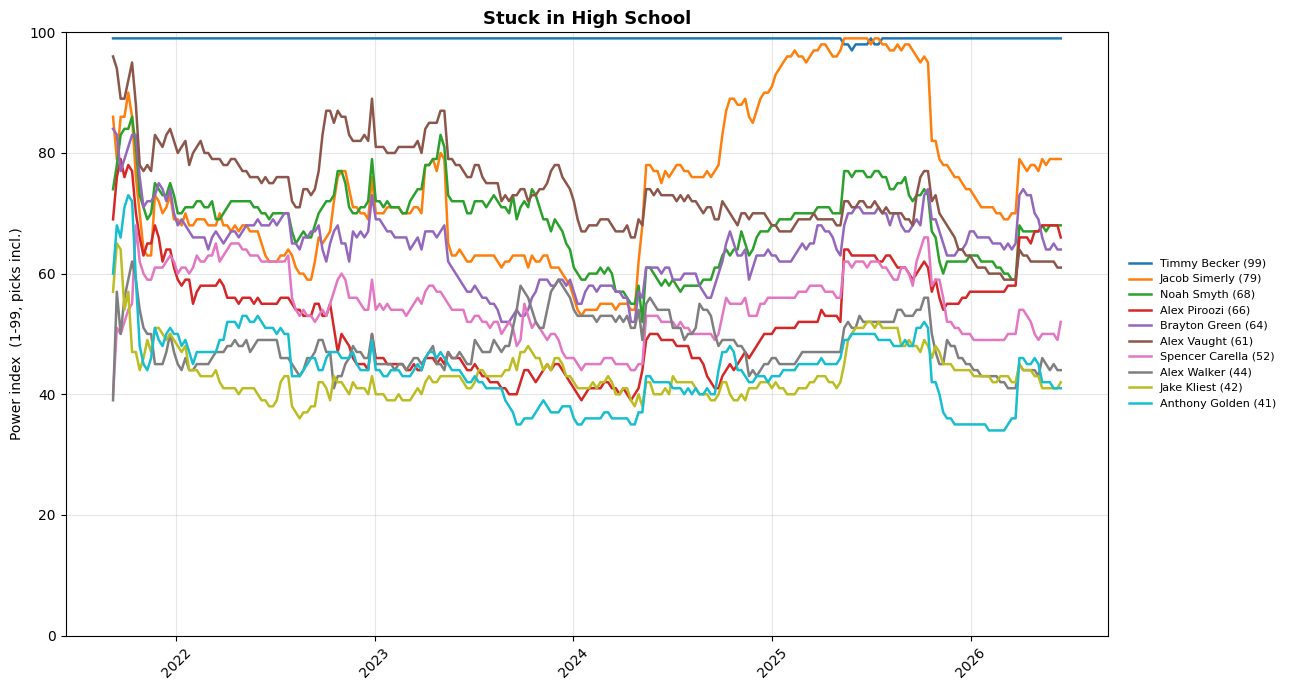

In [4]:
plot_league("730630605066371072")   # Stuck in High School
plt.show()

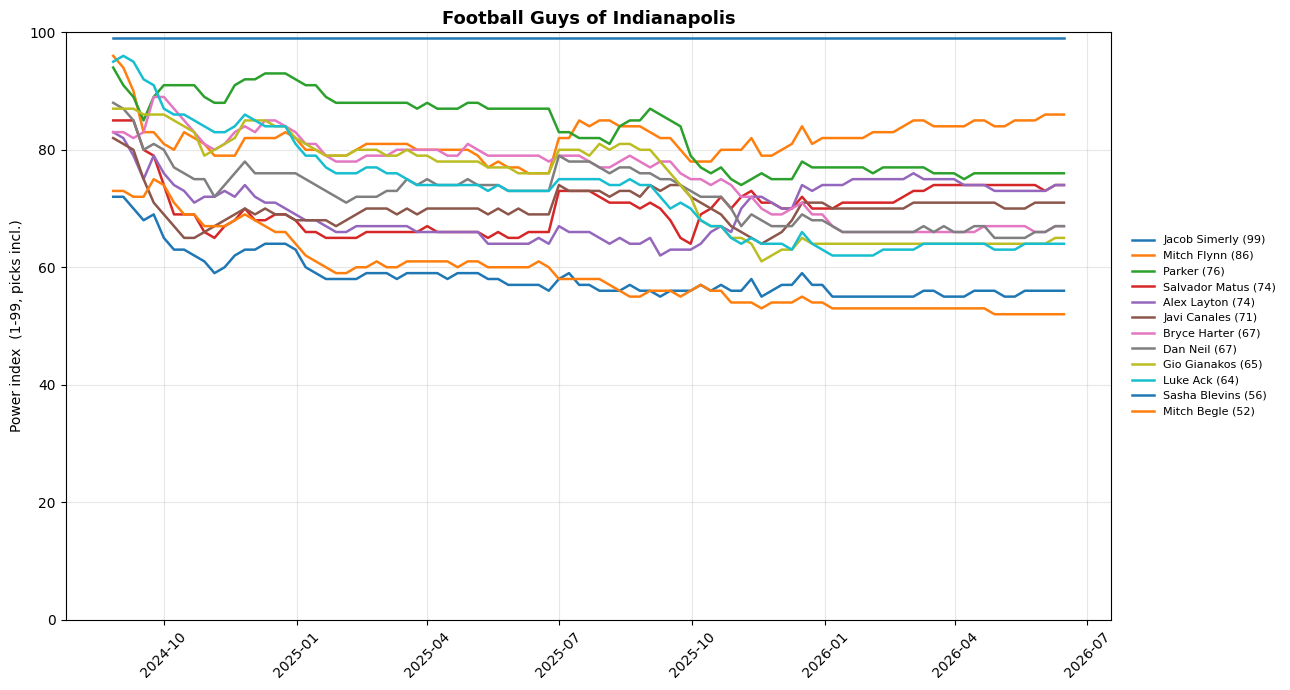

In [5]:
plot_league("1131624152349323264")  # Football Guys of Indianapolis
plt.show()

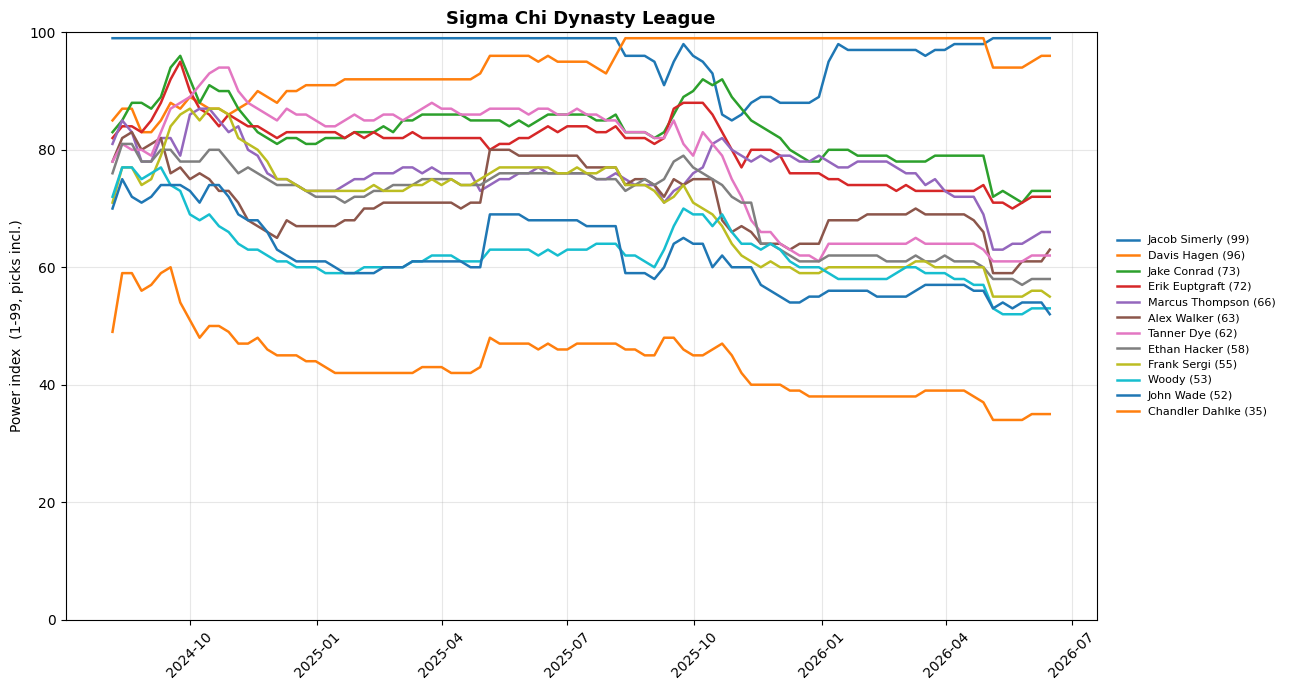

In [6]:
plot_league("1061511485920354304")  # Sigma Chi Dynasty League
plt.show()